# Nível 1 — Dados e primeira análise com LLM

**Parte A — Tratamento e regras (pandas)**
1. Carregar `dados/dados_nivel_1.json`
2. Limpar dados (documentar problemas encontrados e por que foram tratados assim)
3. Normalizar valores para BRL usando `taxa_cambio_usd_brl`
4. Agregações: volume total por cliente; contagem de operações por canal
5. Regra 1 — Fracionamento
6. Regra 2 — Valor atípico
7. Validação das regras (mostrar caso capturado e caso parecido não capturado)

**Parte B — Análise com LLM**
1. Escolher cliente sinalizado, montar prompt para parecer estruturado
2. Validar saída (nivel_risco, tipologia_suspeita, red_flags, justificativa)
3. Tratar resposta malformada
4. Registrar tokens e tempo de resposta
5. Comparar duas versões de prompt

> ⚠️ Lembrete: entregar este notebook com as células já executadas — saída sem resultados commitados não pode ser avaliada.

In [51]:
import json
import pandas as pd

with open("../dados/dados_nivel_1.json", encoding="utf-8") as f:
    dados = json.load(f)

taxa_cambio_usd_brl = dados["taxa_cambio_usd_brl"]
df = pd.DataFrame(dados["operacoes"])
df.head()

,id,cliente_id,data,valor,moeda,canal,tipo,contraparte,observacao
0,OP-0001,CLI-A-1,2026-03-09,18100,BRL,pix,transferencia_enviada,Alfa Comercio LTDA,
1,OP-0002,CLI-A-1,2026-03-09,17300,BRL,pix,transferencia_enviada,Alfa Comercio LTDA,
2,OP-0003,CLI-A-1,2026-03-09,18800,BRL,ted,transferencia_enviada,Beta Servicos ME,
3,OP-0004,CLI-A-1,2026-03-21,3300,BRL,boleto,pagamento,Gama Distribuidora,
4,OP-0005,CLI-A-2,2026-03-14,25900,BRL,ted,transferencia_enviada,Delta Transportes,


In [52]:
# Diagnóstico de qualidade dos dados
print("Linhas totais:", len(df))
print("IDs duplicados:", df["id"].duplicated().sum())
print("Datas ausentes:", df["data"].isna().sum())
print("Moedas distintas:", df["moeda"].unique().tolist())
print("Valores nulos por coluna:")
print(df.isna().sum())

Linhas totais: 20
IDs duplicados: 1
Datas ausentes: 1
Moedas distintas: ['BRL', 'USD']
Valores nulos por coluna:
id             0
cliente_id     0
data           1
valor          0
moeda          0
canal          0
tipo           0
contraparte    0
observacao     0
dtype: int64


## Limpeza dos dados

Problemas de qualidade encontrados no diagnóstico acima e o tratamento aplicado:

1. **Registro duplicado.** A operação `OP-0007` (cliente `CLI-A-3`) aparece duas vezes, com todos os campos idênticos. Tratamento: removida a duplicata por `id` (`drop_duplicates`), mantendo uma única ocorrência. Contar a mesma operação duas vezes infla o volume do cliente e pode disparar falsos positivos nas regras (em especial a Regra 1, que soma valores por data).
2. **Data ausente.** A operação `OP-0017` (cliente `CLI-A-5`) tem `data = None`, com a observação *"data nao capturada pelo sistema"* — indício de falha de captura do sistema legado, não de um evento sem data real. Tratamento: a operação é **mantida** nas agregações que não dependem de data (volume total, contagem por canal, Regra 2), mas é **excluída** do agrupamento por data da Regra 1 (fracionamento), já que sem data não há como saber se ela ocorreu junto de outras operações no mesmo dia. Marcada com a flag `data_ausente` para rastreabilidade.
3. **Moeda mista.** A operação `OP-0013` está em USD, enquanto o restante da base está em BRL. Tratamento: convertida para BRL usando a `taxa_cambio_usd_brl` fixa do próprio arquivo, gerando a coluna `valor_brl`. Todas as agregações, gráficos e regras a seguir usam `valor_brl`, nunca o `valor` bruto — misturar moedas sem converter distorceria qualquer soma, comparação ou visualização.

Nenhum outro problema estrutural foi encontrado (sem valores negativos ou nulos em `valor`, sem `cliente_id`/`canal`/`moeda` fora do domínio esperado).

In [53]:
# Remoção de duplicata exata (mesmo id) e marcação de data ausente
df_clean = df.drop_duplicates(subset=["id"]).copy()
df_clean["data_ausente"] = df_clean["data"].isna()

print(f"Linhas antes: {len(df)}")
print(f"Linhas depois de remover duplicata: {len(df_clean)}")
df_clean[df_clean["data_ausente"] == True]

Linhas antes: 20
Linhas depois de remover duplicata: 19


,id,cliente_id,data,valor,moeda,canal,tipo,contraparte,observacao,data_ausente
17,OP-0017,CLI-A-5,None,4300,BRL,especie,deposito,Gama Distribuidora,data nao capturada pelo sistema,True


In [54]:
# Normalização para BRL usando a taxa fixa do arquivo
df_clean["valor_brl"] = df_clean.apply(
    lambda r: r["valor"] * taxa_cambio_usd_brl if r["moeda"] == "USD" else r["valor"],
    axis=1,
)
df_clean[["id", "cliente_id", "moeda", "valor", "valor_brl"]][df_clean["moeda"] == "USD"]

,id,cliente_id,moeda,valor,valor_brl
13,OP-0013,CLI-A-4,USD,12000,64800.0


## Análise exploratória (quantitativa e qualitativa)

Com os dados já limpos e normalizados para BRL, uma visão quantitativa e visual
antes de seguir para as agregações e regras — inclusive comparando a
distribuição antes e depois da normalização de moeda.

In [55]:
# Resumo quantitativo: valor bruto (moeda mista) vs valor_brl (limpo e normalizado)
print("=== 'valor' bruto (pré-limpeza, moeda mista BRL+USD) ===")
print(df["valor"].describe())

print("\n=== 'valor_brl' pós-limpeza e normalização ===")
print(df_clean["valor_brl"].describe())

print("\n=== Operações por cliente (pós-limpeza) ===")
print(df_clean["cliente_id"].value_counts().sort_values(ascending=False))

print("\n=== Operações por canal (pós-limpeza) ===")
print(df_clean["canal"].value_counts())

print("\n=== Operações por tipo (pós-limpeza) ===")
print(df_clean["tipo"].value_counts())

=== 'valor' bruto (pré-limpeza, moeda mista BRL+USD) ===
count       20.000000
mean     11495.000000
std       7983.369227
min       1400.000000
25%       4175.000000
50%      10400.000000
75%      17225.000000
max      27000.000000
Name: valor, dtype: float64

=== 'valor_brl' pós-limpeza e normalização ===
count       19.000000
mean     13973.684211
std      14724.953956
min       1400.000000
25%       4050.000000
50%       8800.000000
75%      17700.000000
max      64800.000000
Name: valor_brl, dtype: float64

=== Operações por cliente (pós-limpeza) ===
cliente_id
CLI-A-1    4
CLI-A-4    4
CLI-A-5    4
CLI-A-3    3
CLI-A-2    2
CLI-A-6    2
Name: count, dtype: int64

=== Operações por canal (pós-limpeza) ===
canal
pix        8
ted        5
boleto     3
cartao     2
especie    1
Name: count, dtype: int64

=== Operações por tipo (pós-limpeza) ===
tipo
transferencia_enviada     10
pagamento                  5
transferencia_recebida     3
deposito                   1
Name: count, dtype: 

Primeiras impressões:
- Valor: no bruto (moeda mista), distribuição já assimétrica à direita (média 11.495 > mediana 10.400). Depois de limpar e normalizar para BRL (`valor_brl`), o desvio-padrão quase dobra (7.983 → 14.725) e o máximo salta de 27.000 para 64.800. Faz sentido pois o salto foi causado pela operação em USD do `CLI-A-4` revelada pela conversão, não visível enquanto os valores estavam em moedas diferentes.
- Operações por cliente: no bruto, 4 clientes empatavam com 4 operações cada; depois de remover a duplicata, `CLI-A-3` cai para 3 (o número real de operações distintas).
- Canal: PIX segue como o mais comum, com quase o dobro do segundo colocado (TED). Espécie é resíduo, um único registro (justamente a operação com data ausente).
- Tipo: maioria é transferencia_enviada (saída de dinheiro).
- Moeda: a única operação em USD já foi convertida na limpeza acima; toda a análise a partir daqui usa `valor_brl`.

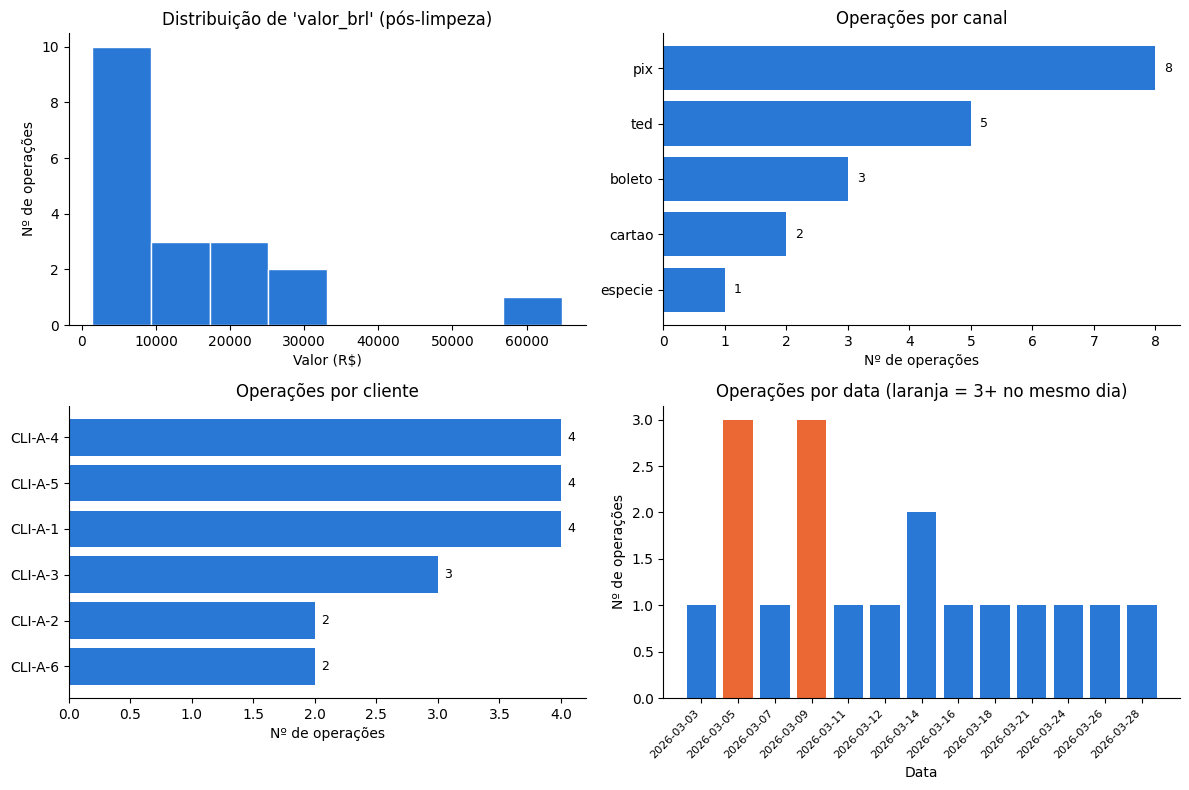

In [56]:
import matplotlib.pyplot as plt

# Paleta categórica fixa (slot 1 = azul: magnitude/padrão; slot 2 = laranja: destaque)
COR_PADRAO = "#2a78d6"
COR_DESTAQUE = "#eb6834"

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Distribuição dos valores já normalizados para BRL (pós-limpeza)
ax = axes[0, 0]
ax.hist(df_clean["valor_brl"], bins=8, color=COR_PADRAO, edgecolor="white")
ax.set_title("Distribuição de 'valor_brl' (pós-limpeza)")
ax.set_xlabel("Valor (R$)")
ax.set_ylabel("Nº de operações")
ax.spines[["top", "right"]].set_visible(False)

# 2. Operações por canal (pós-limpeza)
ax = axes[0, 1]
canal_counts = df_clean["canal"].value_counts().sort_values()
ax.barh(canal_counts.index, canal_counts.values, color=COR_PADRAO)
for i, v in enumerate(canal_counts.values):
    ax.text(v + 0.15, i, str(v), va="center", fontsize=9)
ax.set_title("Operações por canal")
ax.set_xlabel("Nº de operações")
ax.spines[["top", "right"]].set_visible(False)

# 3. Operações por cliente (pós-limpeza)
ax = axes[1, 0]
cliente_counts = df_clean["cliente_id"].value_counts().sort_values()
ax.barh(cliente_counts.index, cliente_counts.values, color=COR_PADRAO)
for i, v in enumerate(cliente_counts.values):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
ax.set_title("Operações por cliente")
ax.set_xlabel("Nº de operações")
ax.spines[["top", "right"]].set_visible(False)

# 4. Operações por data (pós-limpeza; exclui a operação com data ausente) —
#    em laranja, o dia com 3+ operações (pico de possível fracionamento)
ax = axes[1, 1]
ops_por_data = df_clean[~df_clean["data_ausente"]].groupby("data").size().sort_index()
cores_data = [COR_DESTAQUE if v >= 3 else COR_PADRAO for v in ops_por_data.values]
ax.bar(ops_por_data.index, ops_por_data.values, color=cores_data)
ax.set_title("Operações por data (laranja = 3+ no mesmo dia)")
ax.set_xlabel("Data")
ax.set_ylabel("Nº de operações")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Leitura qualitativa (pós-limpeza):**

- **O outlier de `CLI-A-4` já aparece no histograma**: a operação em USD
  convertida (R\$ 64.800) puxa a cauda direita. É a candidata natural à
  Regra 2, que confirma isso matematicamente mais adiante.
- **O `pix` segue como canal dominante** (8 das 19 operações limpas);
- **O gráfico de operações por data agora está coerente**: `2026-03-05`
  aparece corretamente com 3 operações (a duplicata `OP-0007` já foi removida),
  no mesmo patamar de `2026-03-09` (`CLI-A-1`, também 3 operações). É esse par
  parecido que a Regra 1 precisa diferenciar por um limite numérico de soma
  (> R\$ 50.000), não só pela contagem de operações no dia.

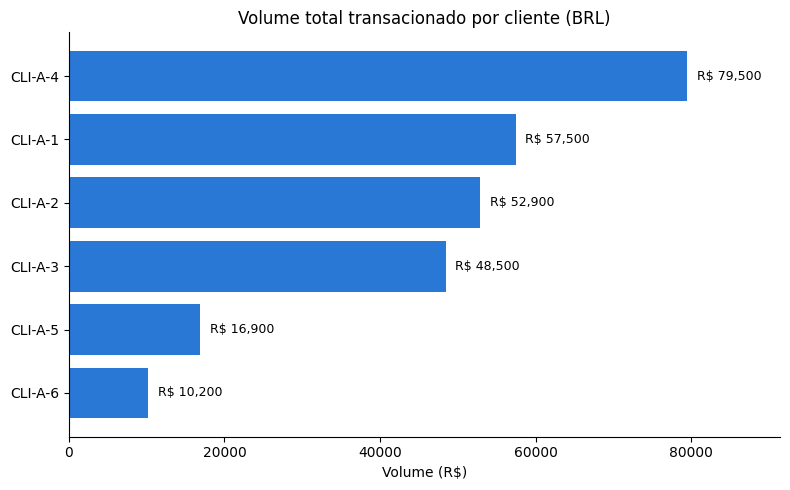

In [57]:
volume_por_cliente = (
    df_clean.groupby("cliente_id")["valor_brl"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
volumes_ordenados = volume_por_cliente.sort_values()
ax.barh(volumes_ordenados.index, volumes_ordenados.values, color=COR_PADRAO)
for i, v in enumerate(volumes_ordenados.values):
    ax.text(v + 1200, i, f"R$ {v:,.0f}", va="center", fontsize=9)
ax.set_title("Volume total transacionado por cliente (BRL)")
ax.set_xlabel("Volume (R$)")
ax.set_xlim(0, volumes_ordenados.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Leitura qualitativa do volume por cliente:**

- **`CLI-A-4` lidera o volume** (R\$ 79.500) apesar de não ter o maior número de
  operações. Indício de que o volume alto vem concentrado em
  poucas transações.
- **`CLI-A-1` aparece em segundo**, e é o volume mais "explicado" por um padrão
  temporal (3 operações concentradas em um único dia) em vez de um valor
  isolado. Candidato natural à Regra 1.
- **`CLI-A-2` e `CLI-A-3` têm volumes parecidos** (R\$ 52.900 e R\$ 48.500) com
  perfis de operação bem diferentes: `CLI-A-2` chega lá com só 2 operações,
  `CLI-A-3` com 3. Reforça que volume total sozinho não diz muito sobre risco
  sem olhar a distribuição das operações no tempo e por valor.
- **`CLI-A-5` e `CLI-A-6` ficam bem abaixo dos demais** (R\$ 16.900 e R\$
  10.200). Nenhum indício de concentração aqui.

## Regra 1 — Fracionamento

Sinaliza o cliente que, em uma mesma data, realizou 3 ou mais operações cuja soma
ultrapassa R\$ 50.000,00, sem que nenhuma operação isolada atinja R\$ 20.000,00.

Só entram no agrupamento por data as operações com `data` conhecida (ver decisão
de limpeza acima sobre `data_ausente`).

In [58]:
LIMITE_SOMA_FRACIONAMENTO = 50_000
LIMITE_OPERACAO_ISOLADA = 20_000
MIN_OPERACOES_FRACIONAMENTO = 3

com_data = df_clean[~df_clean["data_ausente"]]

por_dia = (
    com_data.groupby(["cliente_id", "data"])["valor_brl"]
    .agg(qtd_operacoes="count", soma_valor="sum", maior_operacao="max")
    .reset_index()
)

candidatos_fracionamento = por_dia[
    (por_dia["qtd_operacoes"] >= MIN_OPERACOES_FRACIONAMENTO)
    & (por_dia["soma_valor"] > LIMITE_SOMA_FRACIONAMENTO)
    & (por_dia["maior_operacao"] < LIMITE_OPERACAO_ISOLADA)
]
candidatos_fracionamento

,cliente_id,data,qtd_operacoes,soma_valor,maior_operacao
0,CLI-A-1,2026-03-09,3,54200.0,18800.0


In [59]:
# Flag por operação: True se a operação pertence a um grupo (cliente, data) sinalizado
chaves_fracionamento = set(
    zip(candidatos_fracionamento["cliente_id"], candidatos_fracionamento["data"])
)
df_clean["flag_fracionamento"] = df_clean.apply(
    lambda r: (r["cliente_id"], r["data"]) in chaves_fracionamento, axis=1
)

clientes_flag_fracionamento = sorted(candidatos_fracionamento["cliente_id"].unique().tolist())
print("Clientes sinalizados pela Regra 1 (fracionamento):", clientes_flag_fracionamento)
df_clean[df_clean["flag_fracionamento"] == True]

Clientes sinalizados pela Regra 1 (fracionamento): ['CLI-A-1']


,id,cliente_id,data,valor,moeda,canal,tipo,contraparte,observacao,data_ausente,valor_brl,flag_fracionamento
0,OP-0001,CLI-A-1,2026-03-09,18100,BRL,pix,transferencia_enviada,Alfa Comercio LTDA,,False,18100.0,True
1,OP-0002,CLI-A-1,2026-03-09,17300,BRL,pix,transferencia_enviada,Alfa Comercio LTDA,,False,17300.0,True
2,OP-0003,CLI-A-1,2026-03-09,18800,BRL,ted,transferencia_enviada,Beta Servicos ME,,False,18800.0,True


## Regra 2 — Valor atípico

Sinaliza a operação cujo `valor_brl` seja superior a 5x a mediana dos valores
daquele cliente. Aplicada apenas a clientes com 4 ou mais operações.

In [60]:
MULTIPLICADOR_ATIPICO = 5
MIN_OPERACOES_ATIPICO = 4

qtd_operacoes_cliente = df_clean.groupby("cliente_id")["valor_brl"].transform("count")
mediana_cliente = df_clean.groupby("cliente_id")["valor_brl"].transform("median")

df_clean["flag_valor_atipico"] = (qtd_operacoes_cliente >= MIN_OPERACOES_ATIPICO) & (
    df_clean["valor_brl"] > MULTIPLICADOR_ATIPICO * mediana_cliente
)

clientes_flag_atipico = sorted(
    df_clean.loc[df_clean["flag_valor_atipico"], "cliente_id"].unique().tolist()
)
print("Clientes com ao menos uma operação atípica (Regra 2):", clientes_flag_atipico)
df_clean[df_clean["flag_valor_atipico"]]

Clientes com ao menos uma operação atípica (Regra 2): ['CLI-A-4']


,id,cliente_id,data,valor,moeda,canal,tipo,contraparte,observacao,data_ausente,valor_brl,flag_fracionamento,flag_valor_atipico
13,OP-0013,CLI-A-4,2026-03-24,12000,USD,ted,transferencia_recebida,Zeta Importacao,remessa internacional,False,64800.0,False,True


## Validação das regras

Foco na Regra 1: mostrar um caso que deveria ser capturado e um caso parecido
que não deveria.

- `CLI-A-1` fez 3 operações em `2026-03-09` somando R\$ 54.200, nenhuma isolada
  chegando a R\$ 20.000 → **deve** ser sinalizado.
- `CLI-A-3` fez 3 operações em `2026-03-05` somando R\$ 48.500 (perfil muito
  parecido: mesma quantidade de operações, mesmo canal, valores na mesma faixa)
  mas a soma fica **abaixo** do limite de R\$ 50.000 → **não deve** ser sinalizado.

In [61]:
caso_positivo = df_clean[
    (df_clean["cliente_id"] == "CLI-A-1") & (df_clean["data"] == "2026-03-09")
][["cliente_id", "data", "valor_brl", "flag_fracionamento"]]

caso_negativo = df_clean[
    (df_clean["cliente_id"] == "CLI-A-3") & (df_clean["data"] == "2026-03-05")
][["cliente_id", "data", "valor_brl", "flag_fracionamento"]]

print("Caso que DEVE ser capturado (CLI-A-1, soma R$ 54.200 > R$ 50.000):")
display(caso_positivo)
print(f"Soma: {caso_positivo['valor_brl'].sum():.2f} | Capturado: {caso_positivo['flag_fracionamento'].any()}")

print("\nCaso PARECIDO que NÃO deve ser capturado (CLI-A-3, soma R$ 48.500 < R$ 50.000):")
display(caso_negativo)
print(f"Soma: {caso_negativo['valor_brl'].sum():.2f} | Capturado: {caso_negativo['flag_fracionamento'].any()}")

assert caso_positivo["flag_fracionamento"].all(), "Regra 1 deveria capturar CLI-A-1"
assert not caso_negativo["flag_fracionamento"].any(), "Regra 1 nao deveria capturar CLI-A-3"
print("\nValidação OK: a Regra 1 captura o caso que deveria e não captura o caso parecido que não se enquadra.")

Caso que DEVE ser capturado (CLI-A-1, soma R$ 54.200 > R$ 50.000):


,cliente_id,data,valor_brl,flag_fracionamento
0,CLI-A-1,2026-03-09,18100.0,True
1,CLI-A-1,2026-03-09,17300.0,True
2,CLI-A-1,2026-03-09,18800.0,True


Soma: 54200.00 | Capturado: True

Caso PARECIDO que NÃO deve ser capturado (CLI-A-3, soma R$ 48.500 < R$ 50.000):


,cliente_id,data,valor_brl,flag_fracionamento
6,CLI-A-3,2026-03-05,17200.0,False
7,CLI-A-3,2026-03-05,15200.0,False
8,CLI-A-3,2026-03-05,16100.0,False


Soma: 48500.00 | Capturado: False

Validação OK: a Regra 1 captura o caso que deveria e não captura o caso parecido que não se enquadra.


## Parte B — Análise com LLM

Cálculo (soma, mediana, contagem, comparação com limite) já foi feito em pandas acima. 

O LLM só recebe os números prontos e é usado para **interpretar** e **redigir** o parecer

In [62]:
import os
import time
import json as _json
from typing import List, Literal

from dotenv import load_dotenv
from google import genai
from pydantic import BaseModel, ValidationError

load_dotenv("../.env")

MODEL_NAME = os.environ.get("LLM_MODEL", "gemini-3.5-flash-lite")
client_llm = genai.Client(api_key=os.environ["LLM_API_KEY"])

# Usando pydantic para validar a resposta do LLM, garantindo que o JSON retornado siga o formato esperado.
class ParecerLLM(BaseModel):
    nivel_risco: Literal["baixo", "médio", "alto"]
    tipologia_suspeita: str
    red_flags: List[str]
    justificativa: str

# Contexto com os dados do cliente, já processados e resumidos em pandas, para enviar ao LLM.
def montar_contexto_cliente(cliente_id, df):
    """Reúne só fatos já calculados em pandas — nenhum cálculo é delegado ao LLM."""
    ops = df[df["cliente_id"] == cliente_id]
    return {
        "cliente_id": cliente_id,
        "quantidade_operacoes": int(len(ops)),
        "volume_total_brl": round(float(ops["valor_brl"].sum()), 2),
        "canais_utilizados": ops["canal"].value_counts().to_dict(),
        "tipos_operacao": ops["tipo"].value_counts().to_dict(),
        "contrapartes_distintas": sorted(ops["contraparte"].unique().tolist()),
        "sinalizado_regra_fracionamento": bool(ops["flag_fracionamento"].any()),
        "sinalizado_regra_valor_atipico": bool(ops["flag_valor_atipico"].any()),
        "operacoes": ops[["data", "valor_brl", "canal", "tipo", "contraparte"]].to_dict(
            orient="records"
        ),
    }


cliente_escolhido = "CLI-A-1"  # sinalizado pela Regra 1 (fracionamento)
contexto_cliente = montar_contexto_cliente(cliente_escolhido, df_clean)
contexto_cliente

{'cliente_id': 'CLI-A-1',
 'quantidade_operacoes': 4,
 'volume_total_brl': 57500.0,
 'canais_utilizados': {'pix': 2, 'ted': 1, 'boleto': 1},
 'tipos_operacao': {'transferencia_enviada': 3, 'pagamento': 1},
 'contrapartes_distintas': ['Alfa Comercio LTDA',
  'Beta Servicos ME',
  'Gama Distribuidora'],
 'sinalizado_regra_fracionamento': True,
 'sinalizado_regra_valor_atipico': False,
 'operacoes': [{'data': '2026-03-09',
   'valor_brl': 18100.0,
   'canal': 'pix',
   'tipo': 'transferencia_enviada',
   'contraparte': 'Alfa Comercio LTDA'},
  {'data': '2026-03-09',
   'valor_brl': 17300.0,
   'canal': 'pix',
   'tipo': 'transferencia_enviada',
   'contraparte': 'Alfa Comercio LTDA'},
  {'data': '2026-03-09',
   'valor_brl': 18800.0,
   'canal': 'ted',
   'tipo': 'transferencia_enviada',
   'contraparte': 'Beta Servicos ME'},
  {'data': '2026-03-21',
   'valor_brl': 3300.0,
   'canal': 'boleto',
   'tipo': 'pagamento',
   'contraparte': 'Gama Distribuidora'}]}

In [63]:
def extrair_json(texto):
    """O LLM às vezes envolve o JSON em ```json ... ``` — remove o fence se houver."""
    texto = texto.strip()
    if texto.startswith("```"):
        texto = texto.strip("`")
        if texto.lower().startswith("json"):
            texto = texto[4:]
    return texto.strip()


def chamar_llm(prompt_template, contexto, model_name=MODEL_NAME):
    prompt = prompt_template.format(
        contexto=_json.dumps(contexto, ensure_ascii=False, indent=2)
    )

    inicio = time.time()
    resposta = client_llm.models.generate_content(model=model_name, contents=prompt)
    duracao = time.time() - inicio

    texto_bruto = resposta.text or ""
    uso = resposta.usage_metadata

    resultado = {
        "tempo_resposta_s": round(duracao, 2),
        "tokens_prompt": uso.prompt_token_count if uso else None,
        "tokens_resposta": uso.candidates_token_count if uso else None,
        "tokens_total": uso.total_token_count if uso else None,
        "texto_bruto": texto_bruto,
        "parecer": None,
        "valido": False,
        "erro": None,
    }

    # Tratamento de resposta malformada: JSON inválido ou campos fora do schema
    try:
        parsed = _json.loads(extrair_json(texto_bruto))
        parecer = ParecerLLM(**parsed)
        resultado["parecer"] = parecer.model_dump()
        resultado["valido"] = True
    except (_json.JSONDecodeError, ValidationError) as e:
        resultado["erro"] = str(e)

    return resultado

### Prompt versão 1 — instrução direta e enxuta

In [64]:
PROMPT_V1 = """Você é um analista de prevenção à lavagem de dinheiro. Com base \
nos dados abaixo sobre um cliente (já calculados por regras determinísticas — \
não recalcule nada, apenas interprete), escreva um parecer de risco.

Dados do cliente:
{contexto}

Responda em JSON com os campos: nivel_risco (baixo/médio/alto), \
tipologia_suspeita, red_flags (lista), justificativa.
"""

resultado_v1 = chamar_llm(PROMPT_V1, contexto_cliente)
resultado_v1

{'tempo_resposta_s': 2.05,
 'tokens_prompt': 582,
 'tokens_resposta': 351,
 'tokens_total': 933,
 'texto_bruto': '```json\n{\n  "nivel_risco": "alto",\n  "tipologia_suspeita": "Fracionamento de Valores / Smurfing e Concentração de Operações em Curto Prazo",\n  "red_flags": [\n    "Sinalização positiva para a regra de fracionamento",\n    "Elevado volume de transferências enviadas concentradas em um único dia (09/03/2026)",\n    "Uso de múltiplos canais de movimentação (PIX, TED e boleto)",\n    "Transações de valores expressivos direcionadas a contrapartes comerciais específicas em curto espaço de tempo"\n  ],\n  "justificativa": "O cliente CLI-A-1 apresentou um perfil transacional atípico, caracterizado principalmente pela concentração de 3 transferências enviadas de alto valor (totalizando R$ 54.200,00) em uma única data (09/03/2026) através de PIX e TED, o que resultou no acionamento direto da regra determinística de fracionamento. Embora o volume total (R$ 57.500,00) e a quantidade

### Prompt versão 2 — papel mais detalhado, contrato de saída mais rígido, pede citação dos fatos

In [65]:
PROMPT_V2 = """Você é um analista sênior de prevenção à lavagem de dinheiro (AML) \
em um banco.

REGRAS IMPORTANTES:
- Os cálculos (soma, mediana, contagem, comparação com limites) já foram feitos \
por regras determinísticas. NÃO recalcule nada e NÃO questione os números dados.
- Sua função é interpretar os fatos abaixo e redigir um parecer, citando \
tipologias de lavagem de dinheiro quando pertinente (ex.: fracionamento/smurfing, \
estruturação, uso de contas-passagem, layering).
- Seja específico na justificativa: cite os números já fornecidos (valores, \
quantidade de operações, canais). Não invente dados que não estão no contexto.

Dados do cliente:
{contexto}

Responda ESTRITAMENTE em JSON válido, sem nenhum texto fora do JSON e sem \
markdown, no formato:
{{
  "nivel_risco": "baixo" | "médio" | "alto",
  "tipologia_suspeita": "string curta",
  "red_flags": ["lista", "de", "strings"],
  "justificativa": "2 a 4 frases citando os fatos do contexto"
}}
"""

resultado_v2 = chamar_llm(PROMPT_V2, contexto_cliente)
resultado_v2

{'tempo_resposta_s': 38.36,
 'tokens_prompt': 749,
 'tokens_resposta': 252,
 'tokens_total': 1001,
 'texto_bruto': '{\n  "nivel_risco": "alto",\n  "tipologia_suspeita": "Fracionamento e Estruturação",\n  "red_flags": [\n    "Sinalização positiva para a regra de fracionamento",\n    "Concentração de 3 transferências enviadas de alto valor em um único dia (09/03/2026)",\n    "Uso de múltiplos canais (PIX, TED e boleto) totalizando R$ 57.500,00"\n  ],\n  "justificativa": "O cliente CLI-A-1 realizou um volume total de R$ 57.500,00 distribuído em 4 operações, sendo explicitamente sinalizado pela regra de fracionamento. Destaca-se a concentração de três transferências enviadas em 09/03/2026 nos canais PIX e TED, totalizando R$ 54.200,00 direcionadas a contrapartes distintas (Alfa Comercio LTDA e Beta Servicos ME), padrão clássico de estruturação para burlar mecanismos de controle."\n}',
 'parecer': {'nivel_risco': 'alto',
  'tipologia_suspeita': 'Fracionamento e Estruturação',
  'red_flags':

### Registro de custo/latência e comparação entre as duas versões

Nos dois casos o modelo chegou ao mesmo `nivel_risco` (`alto`), o que é esperado. O cliente já vem sinalizado pela regra determinística, e ambos os prompts deixam claro que o cálculo não deve ser refeito. As diferenças aparecem na forma, não no veredito:

- **Formato da saída.** O prompt v1 (mais enxuto) devolveu o JSON envolto em um
  bloco ```` ```json ... ``` ````, exigindo a limpeza feita em `extrair_json`. O
  prompt v2, por pedir explicitamente "sem nenhum texto fora do JSON e sem
  markdown", devolveu JSON puro — reduz o risco de resposta malformada em
  produção, onde nem sempre haveria esse tratamento de fallback.
- **Tokens: olhar só o total engana.** Nesta execução, `tokens_total` ficou
  parecido entre as versões (v1: 933, v2: 1001) — o que poderia sugerir que o
  custo das duas é equivalente. Mas o total esconde dois efeitos que puxam em
  direções opostas: o prompt v2 é estruturalmente mais pesado (`tokens_prompt`
  582 → 749, +167) porque carrega o contrato de saída e as instruções extras;
  em compensação, exigir um contrato rígido tende a conter a resposta, então
  `tokens_resposta` cai (351 → 252, -99) — quando o modelo tem mais liberdade
  (v1), ele tende a "se alongar" na resposta, o que também está sujeito à
  variância normal de uma chamada de LLM. Nesta execução as duas variações não
  se cancelaram por completo (v2 ainda saiu ~70 tokens mais caro no total),
  mas a comparação correta de custo é decompor em `tokens_prompt` (custo fixo
  do contrato, se repete a cada chamada) vs. `tokens_resposta` (verbosidade,
  varia por execução) — não o total isolado, que pode mascarar de qual dos
  dois lados o custo está vindo.
- **Verbosidade qualitativa.** Coerente com o ponto acima, v1 tende a produzir
  uma `justificativa` e `red_flags` mais longas e com linguagem mais "solta"
  (inferências que não são fatos do contexto, ex.: recomendações de bloqueio
  preventivo). v2, com o contrato mais rígido, tende a citar só números que
  efetivamente estão no contexto (volume total, quantidade de operações),
  reduzindo o risco de a LLM "inventar" dado que não foi fornecido — mesmo
  overhead de prompt, saída mais controlada e mais barata por resposta.
- **Latência não é um eixo confiável de comparação entre os prompts.** Nesta
  execução, v1 respondeu em 2.05s e v2 em 38.36s — um contraste enorme, mas é
  um artefato de variação da API (rate limit da camada gratuita, latência de
  rede, fila do provedor) e não de o prompt v2 ser "mais lento" — em execuções
  anteriores essa mesma tabela já mostrou os dois na casa de 1–2s, às vezes
  com v2 mais rápida que v1. Ao contrário dos tokens (que têm uma explicação
  estrutural ligada ao tamanho do prompt/contrato), a latência varia por
  chamada e não deve ser usada para concluir que uma versão de prompt é
  sistematicamente mais rápida que a outra.

> Os valores exatos de tokens e tempo variam a cada execução (chamada real à
> API) — ver a tabela abaixo para os números desta execução específica.

In [66]:
import pandas as _pd

comparacao = _pd.DataFrame(
    [
        {
            "prompt": "v1",
            "valido": resultado_v1["valido"],
            "nivel_risco": (resultado_v1["parecer"] or {}).get("nivel_risco"),
            "tipologia_suspeita": (resultado_v1["parecer"] or {}).get("tipologia_suspeita"),
            "tempo_resposta_s": resultado_v1["tempo_resposta_s"],
            "tokens_prompt": resultado_v1["tokens_prompt"],
            "tokens_resposta": resultado_v1["tokens_resposta"],
            "tokens_total": resultado_v1["tokens_total"],
        },
        {
            "prompt": "v2",
            "valido": resultado_v2["valido"],
            "nivel_risco": (resultado_v2["parecer"] or {}).get("nivel_risco"),
            "tipologia_suspeita": (resultado_v2["parecer"] or {}).get("tipologia_suspeita"),
            "tempo_resposta_s": resultado_v2["tempo_resposta_s"],
            "tokens_prompt": resultado_v2["tokens_prompt"],
            "tokens_resposta": resultado_v2["tokens_resposta"],
            "tokens_total": resultado_v2["tokens_total"],
        },
    ]
)
comparacao

,prompt,valido,nivel_risco,tipologia_suspeita,tempo_resposta_s,tokens_prompt,tokens_resposta,tokens_total
0,v1,True,alto,Fracionamento de Valores / Smurfing e Concentr...,2.05,582,351,933
1,v2,True,alto,Fracionamento e Estruturação,38.36,749,252,1001


In [67]:
import textwrap

EMOJI_RISCO = {"baixo": "🟢", "médio": "🟡", "alto": "🔴"}


def imprimir_parecer(nome_versao, resultado):
    """Print formatado do parecer — só para leitura humana; o JSON validado
    (resultado['parecer']) continua sendo a fonte de dados estruturada."""
    parecer = resultado["parecer"]
    print("═" * 68)
    print(f" PARECER — {nome_versao}")
    print("═" * 68)

    if not parecer:
        print(f"⚠️  Resposta malformada, não validou o schema: {resultado['erro']}")
        print()
        return

    emoji = EMOJI_RISCO.get(parecer["nivel_risco"], "⚪")
    print(f"{emoji} Nível de risco:      {parecer['nivel_risco'].upper()}")
    print(f"📌 Tipologia suspeita:  {parecer['tipologia_suspeita']}")
    print(f"⏱️  Tempo de resposta:  {resultado['tempo_resposta_s']}s"
          f"   |   🔢 Tokens: {resultado['tokens_total']}")

    print("\n🚩 Red flags:")
    for flag in parecer["red_flags"]:
        print(f"   • {flag}")

    print("\n📝 Justificativa:")
    for linha in textwrap.wrap(parecer["justificativa"], width=64):
        print(f"   {linha}")
    print()


imprimir_parecer("Prompt v1", resultado_v1)
imprimir_parecer("Prompt v2", resultado_v2)

════════════════════════════════════════════════════════════════════
 PARECER — Prompt v1
════════════════════════════════════════════════════════════════════
🔴 Nível de risco:      ALTO
📌 Tipologia suspeita:  Fracionamento de Valores / Smurfing e Concentração de Operações em Curto Prazo
⏱️  Tempo de resposta:  2.05s   |   🔢 Tokens: 933

🚩 Red flags:
   • Sinalização positiva para a regra de fracionamento
   • Elevado volume de transferências enviadas concentradas em um único dia (09/03/2026)
   • Uso de múltiplos canais de movimentação (PIX, TED e boleto)
   • Transações de valores expressivos direcionadas a contrapartes comerciais específicas em curto espaço de tempo

📝 Justificativa:
   O cliente CLI-A-1 apresentou um perfil transacional atípico,
   caracterizado principalmente pela concentração de 3
   transferências enviadas de alto valor (totalizando R$ 54.200,00)
   em uma única data (09/03/2026) através de PIX e TED, o que
   resultou no acionamento direto da regra determinísti